# Imports and initial setup

In [1]:

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import joblib
from src.models import evaluate_model
from src.utils import plot_roc_curve, plot_classification_report

# Create directory to store predictions
predictions_dir = "../data/predictions/"
os.makedirs(predictions_dir, exist_ok=True)  # Create folder if it doesn't exist

# Load processed data
X_train = pd.read_csv("../data/processed/X_train.csv").values
X_test = pd.read_csv("../data/processed/X_test.csv").values
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Performance Analysis of the Proposed XGBoost Model


=== XGBoost ===
CV Accuracy: 99.95% ± 0.003%
Test Accuracy: 99.95%
Precision: 99.95%
Recall: 99.95%
F1 Score: 99.95%
ROC AUC: 1.00


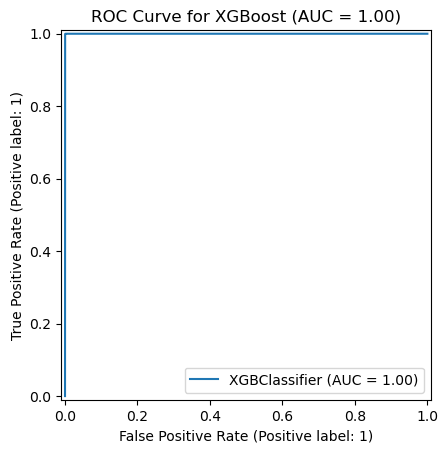

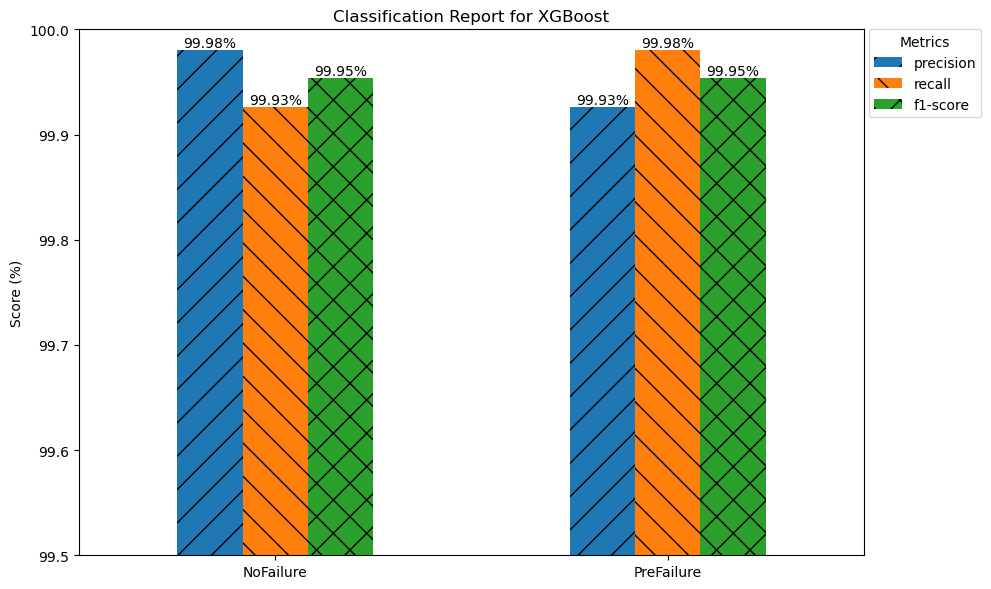

Predictions saved to: ../data/predictions/xgboost_predictions.csv


In [2]:

model_name = "XGBoost"
model = joblib.load("../models/xgboost_model.pkl")

# Evaluate model
metrics, report, y_pred, y_pred_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
print(f"\n=== {model_name} ===")
print(f"CV Accuracy: {metrics['cv_accuracy_mean']:.2f}% ± {metrics['cv_accuracy_std']:.3f}%")
print(f"Test Accuracy: {metrics['test_accuracy']:.2f}%")
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")
print(f"ROC AUC: {metrics['roc_auc']:.2f}")

# Plot ROC curve and classification report
plot_roc_curve(model, X_test, y_test, model_name, f"../roc_curve_{model_name.lower().replace(' ', '_')}.png")
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,          # True labels
    'y_pred': y_pred,          # Binary predictions (0 or 1)
    'y_pred_proba': y_pred_proba  # Probabilities for class 1
})
predictions_file = os.path.join(predictions_dir, f"{model_name.lower().replace(' ', '_')}_predictions.csv")
predictions_df.to_csv(predictions_file, index=False)
print(f"Predictions saved to: {predictions_file}")

## Classification report


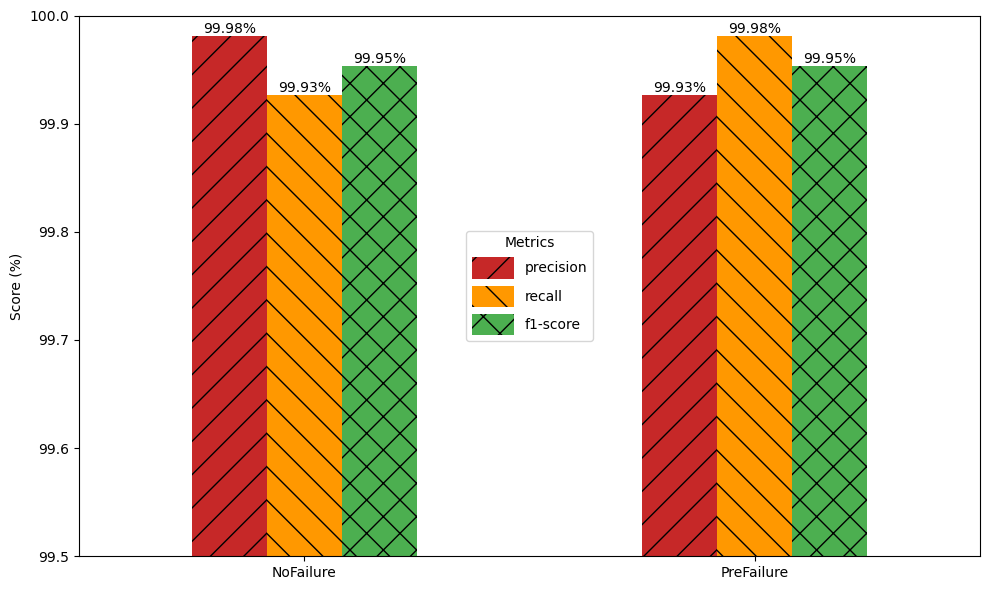

In [1]:

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import joblib
from src.models import evaluate_model
from src.utils import plot_roc_curve, plot_classification_report
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_name = "XGBoost"
import pandas as pd
predictions_df = pd.read_csv(r"C:\Users\maite\OneDrive\Bureau\Contributions\Conference\IEEE IWCMC 2025 XGBoost-based faillures prediction in APU\data\predictions\xgboost_predictions.csv")
y_true = predictions_df['y_true'].values
y_pred = predictions_df['y_pred'].values
y_pred_proba = predictions_df['y_pred_proba'].values
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()
def generate_classification_report(y_test, y_pred):
    return classification_report(y_test, y_pred, output_dict=True)

report = generate_classification_report(y_test, y_pred)
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

## Confusion Matrix


[[512799    379]
 [    99 513079]]


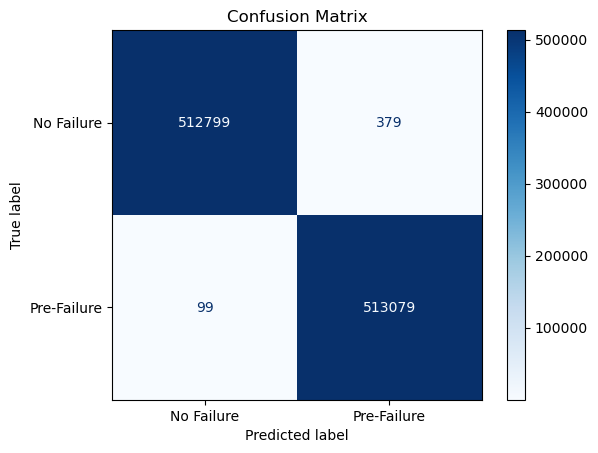

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
predictions_df = pd.read_csv(r"C:\Users\maite\OneDrive\Bureau\Contributions\Conference\IEEE IWCMC 2025 XGBoost-based faillures prediction in APU\data\predictions\xgboost_predictions.csv")
y_true = predictions_df['y_true'].values
y_pred = predictions_df['y_pred'].values
y_pred_proba = predictions_df['y_pred_proba'].values
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

cm = confusion_matrix(y_true, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Pre-Failure"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Performance Analysis of the Baseline Models


## Decision Tree


=== Decision Tree ===
CV Accuracy: 90.49% ± 0.01%
Test Accuracy: 90.45%
Precision: 90.57%
Recall: 90.45%
F1 Score: 90.45%
ROC AUC: 0.94


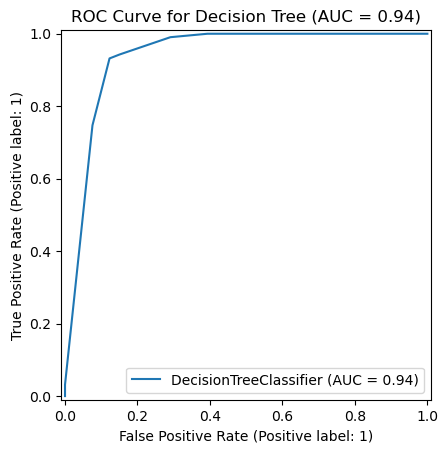

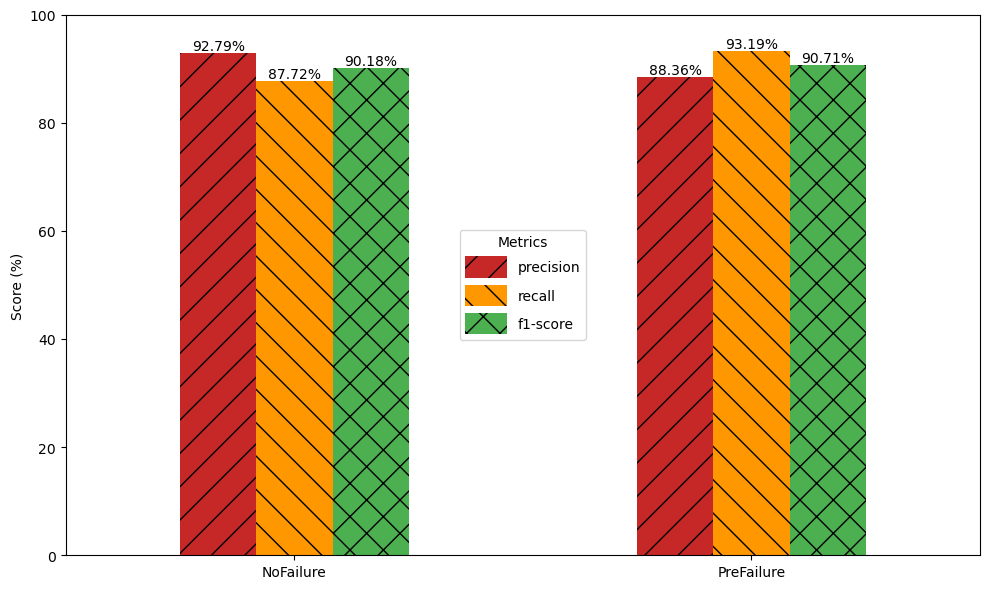

Predictions saved to: ../data/predictions/decision_tree_predictions.csv


In [2]:
model_name = "Decision Tree"
model = joblib.load("../models/dt_model.pkl")

# Evaluate model
metrics, report, y_pred, y_pred_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
print(f"\n=== {model_name} ===")
print(f"CV Accuracy: {metrics['cv_accuracy_mean']:.2f}% ± {metrics['cv_accuracy_std']:.2f}%")
print(f"Test Accuracy: {metrics['test_accuracy']:.2f}%")
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")
print(f"ROC AUC: {metrics['roc_auc']:.2f}")

# Plot ROC curve and classification report
plot_roc_curve(model, X_test, y_test, model_name, f"../roc_curve_{model_name.lower().replace(' ', '_')}.png")
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,          # True labels
    'y_pred': y_pred,          # Binary predictions (0 or 1)
    'y_pred_proba': y_pred_proba  # Probabilities for class 1
})
predictions_file = os.path.join(predictions_dir, f"{model_name.lower().replace(' ', '_')}_predictions.csv")
predictions_df.to_csv(predictions_file, index=False)
print(f"Predictions saved to: {predictions_file}")

## K-Nearest Neighbors 

In [ ]:
model_name = "KNN"
model = joblib.load("../models/knn_model.pkl")

# Evaluate model
metrics, report, y_pred, y_pred_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
print(f"\n=== {model_name} ===")
print(f"CV Accuracy: {metrics['cv_accuracy_mean']:.2f}% ± {metrics['cv_accuracy_std']:.2f}%")
print(f"Test Accuracy: {metrics['test_accuracy']:.2f}%")
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")
print(f"ROC AUC: {metrics['roc_auc']:.2f}")

# Plot ROC curve and classification report
plot_roc_curve(model, X_test, y_test, model_name, f"../roc_curve_{model_name.lower().replace(' ', '_')}.png")
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,          # True labels
    'y_pred': y_pred,          # Binary predictions (0 or 1)
    'y_pred_proba': y_pred_proba  # Probabilities for class 1
})
predictions_file = os.path.join(predictions_dir, f"{model_name.lower().replace(' ', '_')}_predictions.csv")
predictions_df.to_csv(predictions_file, index=False)
print(f"Predictions saved to: {predictions_file}")


=== KNN ===
CV Accuracy: 98.99% ± 0.02%
Test Accuracy: 99.09%
Precision: 99.10%
Recall: 99.09%
F1 Score: 99.09%
ROC AUC: 1.00


## Logistic Regression


=== Logistic Regression ===
CV Accuracy: 69.25% ± 0.06%
Test Accuracy: 69.22%
Precision: 69.32%
Recall: 69.22%
F1 Score: 69.18%
ROC AUC: 0.76


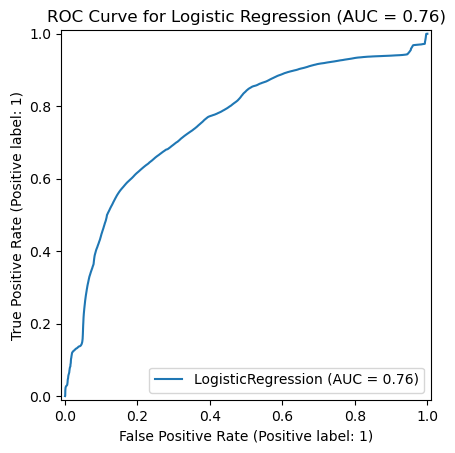

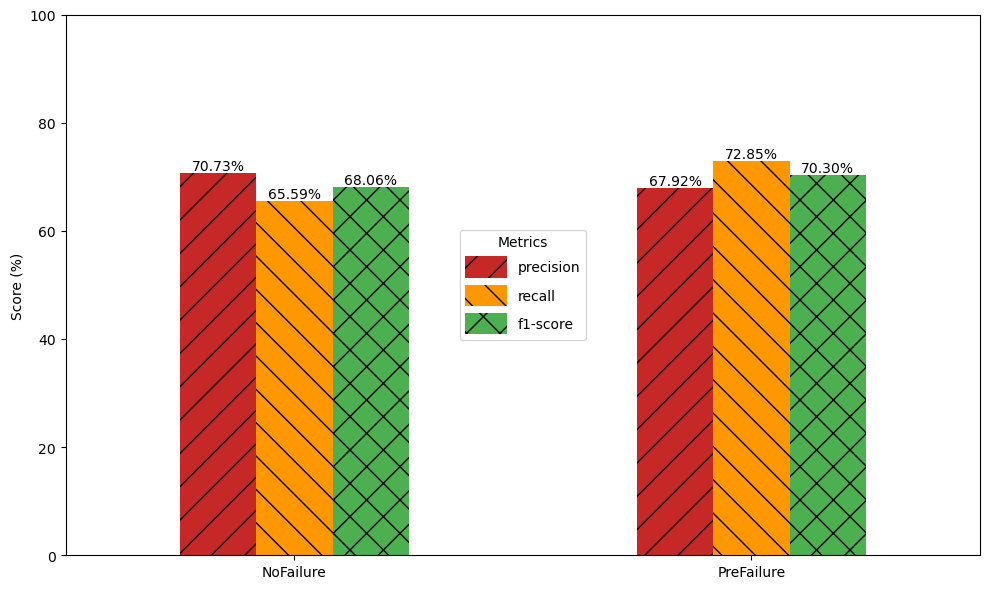

Predictions saved to: ../data/predictions/logistic_regression_predictions.csv


In [3]:
# Cell 7: Logistic Regression
model_name = "Logistic Regression"
model = joblib.load("../models/logistic_model.pkl")

# Evaluate model
metrics, report, y_pred, y_pred_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
print(f"\n=== {model_name} ===")
print(f"CV Accuracy: {metrics['cv_accuracy_mean']:.2f}% ± {metrics['cv_accuracy_std']:.2f}%")
print(f"Test Accuracy: {metrics['test_accuracy']:.2f}%")
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")
print(f"ROC AUC: {metrics['roc_auc']:.2f}")

# Plot ROC curve and classification report
plot_roc_curve(model, X_test, y_test, model_name, f"../roc_curve_{model_name.lower().replace(' ', '_')}.png")
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,          # True labels
    'y_pred': y_pred,          # Binary predictions (0 or 1)
    'y_pred_proba': y_pred_proba  # Probabilities for class 1
})
predictions_file = os.path.join(predictions_dir, f"{model_name.lower().replace(' ', '_')}_predictions.csv")
predictions_df.to_csv(predictions_file, index=False)
print(f"Predictions saved to: {predictions_file}")

##	Naive Bayes 


=== Naive Bayes ===
CV Accuracy: 56.89% ± 0.03%
Test Accuracy: 56.87%
Precision: 64.23%
Recall: 56.87%
F1 Score: 50.47%
ROC AUC: 0.74


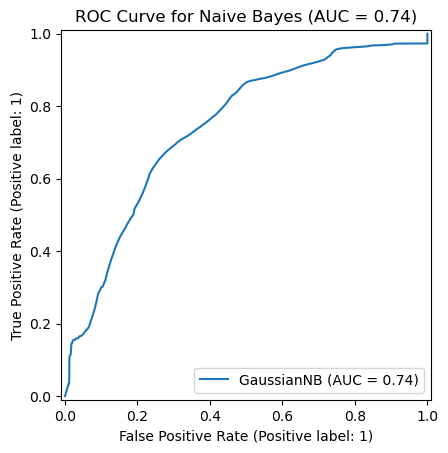

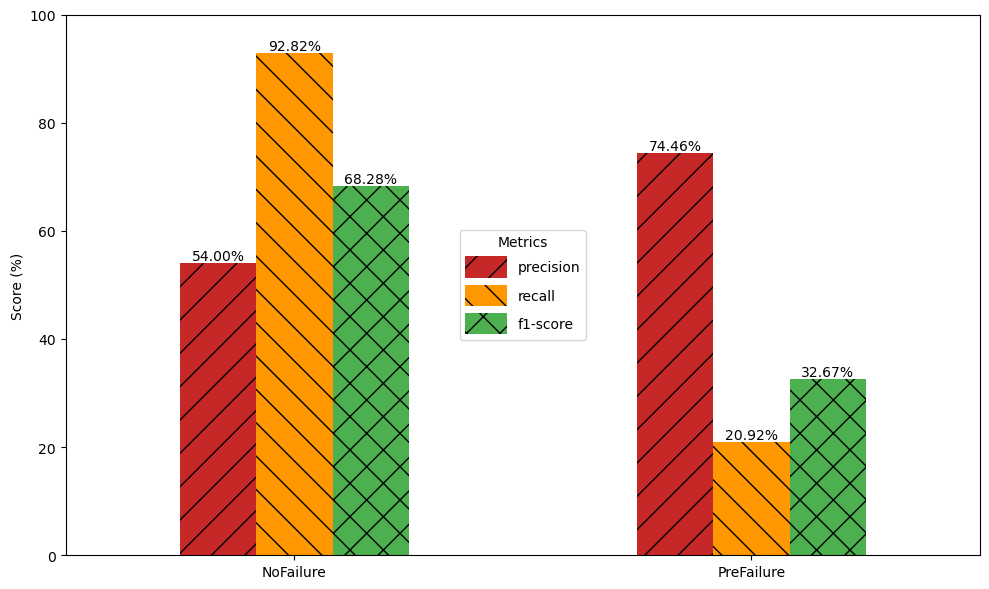

Predictions saved to: ../data/predictions/naive_bayes_predictions.csv


In [4]:
model_name = "Naive Bayes"
model = joblib.load("../models/nb_model.pkl") 

metrics, report, y_pred, y_pred_proba = evaluate_model(model, X_train, y_train, X_test, y_test)
print(f"\n=== {model_name} ===")
print(f"CV Accuracy: {metrics['cv_accuracy_mean']:.2f}% ± {metrics['cv_accuracy_std']:.2f}%")
print(f"Test Accuracy: {metrics['test_accuracy']:.2f}%")
print(f"Precision: {metrics['precision']:.2f}%")
print(f"Recall: {metrics['recall']:.2f}%")
print(f"F1 Score: {metrics['f1']:.2f}%")
print(f"ROC AUC: {metrics['roc_auc']:.2f}")

# Plot ROC curve and classification report
plot_roc_curve(model, X_test, y_test, model_name, f"../roc_curve_{model_name.lower().replace(' ', '_')}.png")
plot_classification_report(report, model_name, f"../classification_report_{model_name.lower().replace(' ', '_')}.png")

# Save predictions
predictions_df = pd.DataFrame({
    'y_true': y_test,          # True labels
    'y_pred': y_pred,          # Binary predictions (0 or 1)
    'y_pred_proba': y_pred_proba  # Probabilities for class 1
})
predictions_file = os.path.join(predictions_dir, f"{model_name.lower().replace(' ', '_')}_predictions.csv")
predictions_df.to_csv(predictions_file, index=False)
print(f"Predictions saved to: {predictions_file}")
